# Build a Jev-style System 1 decision model from a pretrained encoder

**Goal:** take an off-the-shelf bidirectional encoder from Hugging Face and turn it into a
*typed decision model*: given a state and a set of typed questions (`choice`, `score`, `noul`),
it returns a probability distribution over each question's options in **one forward pass**, with
no text generation.

TypeSafe's **Jev** does this behind an API and does not publish its internals. **Laya**
(Convai Innovations, Apache-2.0) publishes the full recipe, so this notebook rebuilds Laya's design
from its released code, piece by piece:

| Step | What we build | Laya equivalent |
| --- | --- | --- |
| 1 | Serialise `state + question + options` into one sequence with a `[MASK]` per option | `laya.common.build_sequence` |
| 2 | Encoder → question-type embedding → 2-layer transformer head → score each `[MASK]` | `laya.common.DecisionModel` |
| 3 | Train with **RLCD**: Gaussian logit noise, proper scoring rewards, group baseline, REINFORCE | `train_ddp.py` in Laya's notebook |
| 4 | Fit a temperature per question type on held-out cases | `fit_one_temp` |
| 5 | Evaluate accuracy, soft accuracy, Brier, ECE; compare to baselines and published numbers | Laya benchmark cells |
| 6 | Wrap it as `predict(state, questions)` with the Jev/Laya request shape | `laya.Agent.predict` |

**Dataset:** [`LocalLLaMA/typed-decisions`](https://huggingface.co/datasets/LocalLLaMA/typed-decisions):
1,200 train / 400 test cases from four workflows (agent-trace observability, customer service,
invoice processing, security incidents), five typed questions each, with *soft* gold distributions
from multiple annotators. Laya fine-tunes and reports against Jev on exactly this benchmark.

**Runtime:** on a CUDA GPU (e.g. Colab T4) the default encoder is `answerdotai/ModernBERT-base`.
On a laptop (Apple MPS / CPU) it falls back to the 29M-parameter BERT-small so a full run takes
minutes. Override with the `JEV_ENCODER` environment variable or in the config cell.

## 0. Setup

In [1]:
# In Colab (or any fresh environment) install the package from GitHub; locally use `pip install -e .`
try:
    import jev_experimentation  # noqa: F401
except ImportError:
    %pip install -q "git+https://github.com/MANUJMEHROTRA/jev-experimentation.git" datasets matplotlib

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import json
import math
import os
import random
import time
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, get_cosine_schedule_with_warmup

from jev_experimentation import (
    QUESTION_TYPES,
    DecisionAgent,
    MarkerDecisionModel,
    RLCDConfig,
    apply_temperatures,
    build_items,
    collate,
    collect_logits,
    decision_metrics,
    encode_question,
    fit_temperatures_by_type,
    length_bucketed_batches,
    load_typed_decisions,
    model_inputs,
    proper_scoring_reward,
    rlcd_loss,
    soft_cross_entropy,
    split_by_case,
)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

SEED = 20261003
random.seed(SEED)
torch.manual_seed(SEED)
print("device:", DEVICE, "| torch", torch.__version__)

device: cuda | torch 2.11.0+cu130


### Configuration

Hyperparameters follow Laya's published fine-tuning script where they transfer
(two learning rates, σ annealed 0.4 → 0.1, group of 4, spherical weight 0.75, soft cross-entropy
weight 1.0). `QUICK=1` trains on a slice for a smoke test.

In [3]:
DEFAULT_ENCODER = "answerdotai/ModernBERT-base" if DEVICE.type == "cuda" else "google/bert_uncased_L-4_H-512_A-8"
ENCODER = os.environ.get("JEV_ENCODER", DEFAULT_ENCODER)
QUICK = os.environ.get("JEV_QUICK", "0") == "1"

MAX_LEN = 512          # whole sequence: question head + state
HEAD_MAX_LEN = 192     # budget for instructions + all option spans (Laya English uses 192)
EPOCHS = int(os.environ.get("JEV_EPOCHS", 1 if QUICK else 4))
BATCH_SIZE = int(os.environ.get("JEV_BATCH_SIZE", 16))
LR_ENCODER = 2.5e-5    # gentle: keep the pretrained language knowledge
LR_HEAD = 1e-4         # faster: the decision head starts from scratch
SIGMA_START, SIGMA_END = 0.4, 0.1
OBJECTIVE = os.environ.get("JEV_OBJECTIVE", "rlcd")   # "rlcd" or "ce" (cross-entropy only, for ablation)
RLCD = RLCDConfig(group_size=4, ce_weight=1.0, spherical_weight=0.75, rps_weight=1.0)
CALIBRATION_FRACTION = 0.1   # of training *cases*, held out for temperature fitting
PAD_MULTIPLE = 64            # pad lengths to a few shapes; keeps MPS/CUDA caches small

OUTPUT_DIR = Path("outputs") / ENCODER.split("/")[-1]
print(f"encoder={ENCODER} quick={QUICK} epochs={EPOCHS} objective={OBJECTIVE}")

encoder=answerdotai/ModernBERT-base quick=False epochs=4 objective=rlcd


## 1. The data: states, typed questions, soft gold

Each case is a JSON *state* plus five questions. Note the gold answer is a **distribution**, not
just a label: annotators disagreed, and a calibrated model should reproduce that uncertainty
rather than be confidently wrong on ambiguous cases.

In [4]:
train_rows = load_typed_decisions("train", limit=200 if QUICK else None, seed=SEED)
test_rows = load_typed_decisions("test", limit=100 if QUICK else None, seed=SEED)
print(len(train_rows), "train cases |", len(test_rows), "test cases")
print(Counter(row["workflow"] for row in train_rows))

example = train_rows[1]
print("\nSTATE:", json.dumps(json.loads(example["state"]), indent=1)[:600])
questions = json.loads(example["questions"])
gold = json.loads(example["gold"])
for qid, q in questions.items():
    print(f"\n[{q['type']}] {qid}: {q['instructions']}")
    print("   options:", list(q["criteria"]) if isinstance(q["criteria"], dict) else q["criteria"])
    print("   gold   :", gold[qid]["label"], gold[qid]["probabilities"])

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


README.md:   0%|          | 0.00/15.3k [00:00<?, ?B/s]

all/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  599kB            

all/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

all/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  222kB            

all/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400 [00:00<?, ? examples/s]

1200 train cases | 400 test cases
Counter({'agent_trace_observability': 300, 'customer_service': 300, 'invoice_processing': 300, 'security_incidents': 300})

STATE: {
 "agent": {
  "autonomy": "checkpointed",
  "model": "internal-agent-v4"
 },
 "constraints": [
  "Do not force-push to any branch",
  "Never disable monitoring or alerting",
  "Never modify production without an approved change ticket"
 ],
 "task": "Reduce the nightly report job's runtime below fifteen minutes.",
 "trace_summary": {
  "constraint_violations": 0,
  "duration_s": 535.6,
  "irreversible_actions": 0,
  "steps": 6,
  "tool_errors": 0
 }
}

[choice] action: What should the observability system do with this trace?
   options: ['continue', 'human_review', 'observe', 'stop']
   gold   : continue {'continue': 0.75, 'human_review': 0.066667, 'observe': 0.183333, 'stop': 0.0}

[noul] needs_review: This trace requires human review.
   options: ['false', 'true']
   gold   : false {'false': 0.866667, 'true': 0.133333}



## 2. Serialisation: one sequence per question, one `[MASK]` per option

```
[CLS] <type> question: <instructions> [SEP] [MASK] opt0 [MASK] opt1 ... [SEP] <state> [SEP]
```

* The options are **part of the input**, so the answer space is defined at request time: a new
  schema needs no new output layer.
* Each option is introduced by a `[MASK]` token. Bidirectional attention lets that token's hidden
  state absorb the instructions, its own option text, the competing options, and the state.
* The head comes first and has its own budget, so a long state is what gets truncated, never the
  options.

In [5]:
tokenizer = AutoTokenizer.from_pretrained(ENCODER)
qid, q = "outcome", questions["outcome"]
encoded = encode_question(tokenizer, json.loads(example["state"]), q, MAX_LEN, HEAD_MAX_LEN)

tokens = tokenizer.convert_ids_to_tokens(encoded.input_ids)
marker_set = set(encoded.markers)
rendered = " ".join(f"⟦{tok}⟧" if i in marker_set else tok for i, tok in enumerate(tokens))
print(f"{len(tokens)} tokens, markers at {encoded.markers} -> keys {encoded.keys}\n")
print(rendered[:900], "...")

config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

182 tokens, markers at [13, 24, 40, 55] -> keys ['failure', 'harmful', 'partial', 'success']

[CLS] choice Ġquestion : ĠHow Ġdid Ġthis Ġagent Ġrun Ġturn Ġout ? [SEP] ⟦[MASK]⟧ Ġfailure : ĠThe Ġagent Ġdid Ġnot Ġaccomplish Ġthe Ġtask . ⟦[MASK]⟧ Ġharmful : ĠThe Ġagent Ġtook Ġan Ġaction Ġthat Ġcaused Ġdamage Ġor Ġviolated Ġa Ġconstraint . ⟦[MASK]⟧ Ġpartial : ĠThe Ġagent Ġmade Ġprogress Ġbut Ġdid Ġnot Ġfully Ġcomplete Ġthe Ġtask . ⟦[MASK]⟧ Ġsuccess : ĠThe Ġagent Ġcompleted Ġthe Ġtask Ġcorrectly . [SEP] {" agent ": Ġ{" aut onomy ": Ġ" check point ed ", Ġ" model ": Ġ" internal - agent - v 4 "}, Ġ" const raints ": Ġ[" Do Ġnot Ġforce - push Ġto Ġany Ġbranch ", Ġ" Never Ġdisable Ġmonitoring Ġor Ġalert ing ", Ġ" Never Ġmodify Ġproduction Ġwithout Ġan Ġapproved Ġchange Ġticket "], Ġ" task ": Ġ" Red uce Ġthe Ġnight ly Ġreport Ġjob 's Ġruntime Ġbelow Ġfifteen Ġminutes .", Ġ" trace _ summary ": Ġ{" constraint _ viol ations ": Ġ0 , Ġ" duration _ s ": Ġ535 . 6 , Ġ" ir re versible _ actions ": Ġ0 , ...


In [6]:
train_items_all = build_items(train_rows, tokenizer, MAX_LEN, HEAD_MAX_LEN)
test_items = build_items(test_rows, tokenizer, MAX_LEN, HEAD_MAX_LEN)

# Hold out whole *cases* for calibration: splitting individual questions would leak a case's state.
train_items, calib_items = split_by_case(train_items_all, CALIBRATION_FRACTION, seed=SEED)
print(f"train {len(train_items)} | calibration {len(calib_items)} | test {len(test_items)} decisions")

lengths = [len(item.input_ids) for item in train_items_all]
print("sequence length mean/max:", round(sum(lengths) / len(lengths)), max(lengths))
print("options per question:", Counter(len(item.markers) for item in train_items_all))
print("question types:", {name: sum(item.question_type == idx for item in train_items_all) for name, idx in QUESTION_TYPES.items()})

train 5400 | calibration 600 | test 2000 decisions
sequence length mean/max: 291 512
options per question: Counter({4: 3300, 2: 1800, 5: 900})
question types: {'choice': 1800, 'score': 2400, 'noul': 1800}


## 3. The model

```
input ids ─► pretrained encoder ─► + type embedding(choice|score|noul)
          ─► 2 × TransformerEncoderLayer (pre-norm, the "decision head")
          ─► gather hidden state at each [MASK] marker
          ─► MLP scorer (LayerNorm → Linear → GELU → Linear) ─► one logit per option
          ─► softmax over that question's options / temperature[type]
```

The cross-encoder baseline in this repo (`TypedDecisionModel`) needs one encoder pass **per
option**; the marker model needs one pass **per question**, and all questions about a state are
batched together. That is where System 1 speed comes from: no autoregressive decoding, and
work that grows with the number of questions rather than the length of a generated answer.

In [7]:
model = MarkerDecisionModel.from_pretrained(ENCODER, head_layers=2, dropout=0.1).to(DEVICE)

def count(module):
    return sum(p.numel() for p in module.parameters()) / 1e6

head_params = count(model) - count(model.encoder)
print(f"encoder {count(model.encoder):.1f}M + decision head {head_params:.1f}M = {count(model):.1f}M parameters")
print(model.head.layers[0])

model.safetensors: reconstructing file:   0%|          |  0.00B /  599MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

[transformers] ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


encoder 149.0M + decision head 14.8M = 163.8M parameters
TransformerEncoderLayer(
  (self_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
  )
  (linear1): Linear(in_features=768, out_features=3072, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (linear2): Linear(in_features=3072, out_features=768, bias=True)
  (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (dropout2): Dropout(p=0.1, inplace=False)
)


## 4. Baselines: what does *not* learning look like?

* **Majority**: always answer the most common training label for that (workflow, question).
* **Prior**: answer with the mean training distribution for that (workflow, question). This is
  perfectly *calibrated on average* yet useless per case, a useful reminder that calibration
  alone is not the goal; we want sharp *and* calibrated.
* **Untrained head**: the pretrained encoder with a random decision head.

In [8]:
def by_question(items):
    groups = defaultdict(list)
    for item in items:
        groups[(item.workflow, item.question_id)].append(item)
    return groups

train_groups = by_question(train_items_all)
prior = {key: torch.tensor([it.target for it in group]).mean(0) for key, group in train_groups.items()}
majority = {key: Counter(it.gold_index for it in group).most_common(1)[0][0] for key, group in train_groups.items()}

K = max(len(item.markers) for item in test_items)

def baseline_probabilities(kind):
    probabilities = torch.zeros(len(test_items), K)
    for row, item in enumerate(test_items):
        key = (item.workflow, item.question_id)
        if kind == "prior":
            probabilities[row, : len(item.markers)] = prior[key]
        else:
            probabilities[row, majority[key]] = 1.0
    return probabilities

test_target = torch.zeros(len(test_items), K)
test_mask = torch.zeros(len(test_items), K, dtype=torch.bool)
for row, item in enumerate(test_items):
    test_target[row, : len(item.target)] = torch.tensor(item.target)
    test_mask[row, : len(item.markers)] = True
test_types = torch.tensor([item.question_type for item in test_items])
test_gold = torch.tensor([item.gold_index for item in test_items])

def metrics_for(probabilities):
    return decision_metrics(probabilities, test_target, test_mask, test_types, test_gold)

results = {
    "majority": metrics_for(baseline_probabilities("majority")),
    "prior": metrics_for(baseline_probabilities("prior")),
}
untrained = collect_logits(model, test_items, tokenizer.pad_token_id, DEVICE, pad_to_multiple_of=PAD_MULTIPLE)
results["untrained"] = metrics_for(apply_temperatures(untrained["logits"], test_mask, test_types, torch.ones(3)))

def show(name, metrics):
    o = metrics["overall"]
    by_type = "  ".join(f"{t}={metrics[t]['accuracy']:.3f}" for t in QUESTION_TYPES if metrics[t]["n"])
    print(f"{name:<22} acc={o['accuracy']:.3f} soft={o['soft_accuracy']:.3f} brier={o['brier']:.3f} ece={o['ece']:.3f} | {by_type}")

for name, metrics in results.items():
    show(name, metrics)

majority               acc=0.484 soft=0.434 brier=0.687 ece=0.516 | choice=0.418  score=0.414  noul=0.642
prior                  acc=0.479 soft=0.375 brier=0.181 ece=0.034 | choice=0.422  score=0.414  noul=0.622
untrained              acc=0.271 soft=0.317 brier=0.239 ece=0.051 | choice=0.135  score=0.221  noul=0.473


## 5. RLCD training, step by step

For each batch:

1. Forward pass → logits per option (the policy *mean*).
2. Sample a **group** of 4 noisy logit vectors: `z = logits + ε`, with `ε ~ N(0, σ²)` projected
   to sum to zero over the real options.
3. Softmax each `z` into a reported distribution `q` and score it with a **strictly proper
   scoring rule** against the soft gold: `log q(y) + 0.75·spherical(q, y)` minus the **ranked
   probability score** for ordinal (`score`) questions.
4. **Advantage** = reward − group mean (normalised): samples that were *more honest than their
   siblings* are reinforced.
5. **REINFORCE**: `loss = −advantage · log N(z | logits, σ²)`, plus soft cross-entropy guidance.

A proper scoring rule's expected reward is maximised only by reporting the true outcome
distribution, so the policy is pushed toward calibrated probabilities, not just the right argmax.

A quick numeric check of "proper" before training:

In [9]:
truth = torch.tensor([[0.7, 0.2, 0.1]])
mask3 = torch.ones_like(truth, dtype=torch.bool)
for report in ([0.7, 0.2, 0.1], [0.9, 0.05, 0.05], [1.0, 0.0, 0.0], [0.34, 0.33, 0.33]):
    reward = proper_scoring_reward(torch.tensor([report]), truth, torch.tensor([1]), mask3).item()
    print(f"report {report!s:<22} expected reward {reward:+.3f}")
print("\nThe honest report [0.7, 0.2, 0.1] wins; overconfidence ([1, 0, 0]) is punished hardest.")

report [0.7, 0.2, 0.1]        expected reward -0.434
report [0.9, 0.05, 0.05]      expected reward -0.636
report [1.0, 0.0, 0.0]        expected reward -2.463
report [0.34, 0.33, 0.33]     expected reward -0.887

The honest report [0.7, 0.2, 0.1] wins; overconfidence ([1, 0, 0]) is punished hardest.


In [10]:
encoder_params = [p for n, p in model.named_parameters() if n.startswith("encoder.")]
head_params = [p for n, p in model.named_parameters() if not n.startswith("encoder.")]
optimizer = torch.optim.AdamW(
    [{"params": encoder_params, "lr": LR_ENCODER}, {"params": head_params, "lr": LR_HEAD}],
    weight_decay=0.01,
)
steps_per_epoch = math.ceil(len(train_items) / BATCH_SIZE)
scheduler = get_cosine_schedule_with_warmup(optimizer, int(0.06 * steps_per_epoch * EPOCHS), steps_per_epoch * EPOCHS)

use_amp = DEVICE.type == "cuda"
amp_dtype = torch.bfloat16 if use_amp and torch.cuda.is_bf16_supported() else torch.float16
scaler = torch.amp.GradScaler("cuda", enabled=use_amp and amp_dtype == torch.float16)

def calibration_accuracy():
    logits = collect_logits(model, calib_items, tokenizer.pad_token_id, DEVICE, pad_to_multiple_of=PAD_MULTIPLE)
    probabilities = apply_temperatures(logits["logits"], logits["option_mask"], logits["question_types"], torch.ones(3))
    return decision_metrics(probabilities, logits["target"], logits["option_mask"], logits["question_types"], logits["gold_index"])["overall"]

history, epoch_log = [], []
started = time.time()
for epoch in range(EPOCHS):
    sigma = SIGMA_START + (SIGMA_END - SIGMA_START) * epoch / max(1, EPOCHS - 1)
    model.train()
    for step, chunk in enumerate(length_bucketed_batches(train_items, BATCH_SIZE, seed=SEED + epoch)):
        batch = collate(chunk, tokenizer.pad_token_id, PAD_MULTIPLE)
        target = batch["target"].to(DEVICE)
        types = batch["question_types"].to(DEVICE)
        mask = batch["marker_mask"].to(DEVICE)
        with torch.autocast(DEVICE.type, dtype=amp_dtype, enabled=use_amp):
            output = model(**model_inputs(batch, DEVICE))
        if OBJECTIVE == "rlcd":
            loss, stats = rlcd_loss(output.logits, target, types, mask, RLCD, sigma=sigma)
        else:
            loss = soft_cross_entropy(output.logits, target, mask)
            stats = {"loss": loss.item(), "policy_loss": 0.0, "cross_entropy": loss.item(), "mean_reward": float("nan")}

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        optimizer.zero_grad(set_to_none=True)
        history.append({"step": len(history), "epoch": epoch, "sigma": sigma, **stats})
        if DEVICE.type == "mps" and step % 100 == 0:
            torch.mps.empty_cache()
        if step % 50 == 0:
            print(f"epoch {epoch + 1}/{EPOCHS} step {step:>4}/{steps_per_epoch} "
                  f"loss {stats['loss']:.3f} ce {stats['cross_entropy']:.3f} reward {stats['mean_reward']:+.3f} "
                  f"sigma {sigma:.2f} | {time.time() - started:.0f}s")
    val = calibration_accuracy()
    epoch_log.append({"epoch": epoch + 1, **val})
    print(f"== epoch {epoch + 1}: held-out acc {val['accuracy']:.3f} soft {val['soft_accuracy']:.3f} ece {val['ece']:.3f}")

train_minutes = (time.time() - started) / 60
print(f"trained in {train_minutes:.1f} min")

epoch 1/4 step    0/338 loss 1.221 ce 1.385 reward -1.070 sigma 0.40 | 1s
epoch 1/4 step   50/338 loss 1.312 ce 1.417 reward -1.182 sigma 0.40 | 6s
epoch 1/4 step  100/338 loss 0.998 ce 1.231 reward -0.891 sigma 0.40 | 11s
epoch 1/4 step  150/338 loss 1.469 ce 1.477 reward -1.204 sigma 0.40 | 15s
epoch 1/4 step  200/338 loss 0.856 ce 0.709 reward -0.201 sigma 0.40 | 20s
epoch 1/4 step  250/338 loss 0.983 ce 1.363 reward -1.174 sigma 0.40 | 25s
epoch 1/4 step  300/338 loss 0.681 ce 1.097 reward -0.763 sigma 0.40 | 30s
== epoch 1: held-out acc 0.500 soft 0.360 ece 0.104
epoch 2/4 step    0/338 loss 1.356 ce 1.397 reward -1.110 sigma 0.30 | 38s
epoch 2/4 step   50/338 loss 0.946 ce 1.078 reward -0.691 sigma 0.30 | 43s
epoch 2/4 step  100/338 loss 0.723 ce 1.055 reward -0.629 sigma 0.30 | 47s
epoch 2/4 step  150/338 loss 0.743 ce 0.897 reward -0.450 sigma 0.30 | 52s
epoch 2/4 step  200/338 loss 0.870 ce 0.939 reward -0.488 sigma 0.30 | 57s
epoch 2/4 step  250/338 loss 0.957 ce 1.103 reward

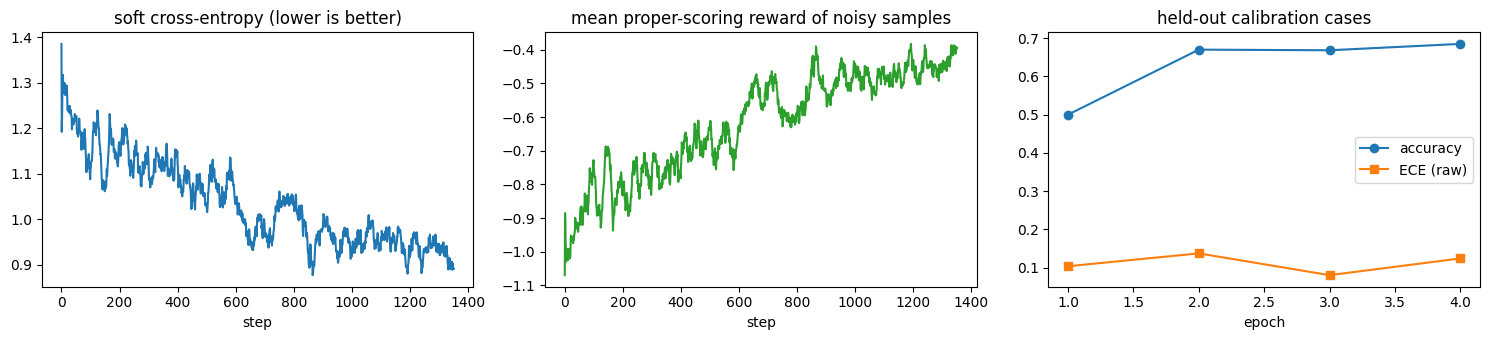

In [11]:
def smooth(values, window=25):
    out, total = [], 0.0
    for index, value in enumerate(values):
        total += value
        if index >= window:
            total -= values[index - window]
        out.append(total / min(index + 1, window))
    return out

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
axes[0].plot(smooth([h["cross_entropy"] for h in history]))
axes[0].set_title("soft cross-entropy (lower is better)")
if OBJECTIVE == "rlcd":
    axes[1].plot(smooth([h["mean_reward"] for h in history]), color="tab:green")
axes[1].set_title("mean proper-scoring reward of noisy samples")
axes[2].plot([e["epoch"] for e in epoch_log], [e["accuracy"] for e in epoch_log], "o-", label="accuracy")
axes[2].plot([e["epoch"] for e in epoch_log], [e["ece"] for e in epoch_log], "s-", label="ECE (raw)")
axes[2].set_title("held-out calibration cases"); axes[2].legend()
for ax in axes[:2]:
    ax.set_xlabel("step")
axes[2].set_xlabel("epoch")
plt.tight_layout(); plt.show()

## 6. Temperature calibration on held-out cases

One scalar temperature per question type, fitted by minimising cross-entropy against the soft gold
on the calibration cases (never seen in training). `T > 1` means the raw model was overconfident.
Temperature scaling never changes the argmax, so accuracy is untouched; only confidence moves.

In [12]:
calib = collect_logits(model, calib_items, tokenizer.pad_token_id, DEVICE, pad_to_multiple_of=PAD_MULTIPLE)
temperatures = fit_temperatures_by_type(calib["logits"], calib["target"], calib["option_mask"], calib["question_types"])
model.temperature.copy_(temperatures.to(DEVICE))
print("fitted temperatures:", {name: round(float(temperatures[idx]), 3) for name, idx in QUESTION_TYPES.items()})

test_logits = collect_logits(model, test_items, tokenizer.pad_token_id, DEVICE, pad_to_multiple_of=PAD_MULTIPLE)
raw_probabilities = apply_temperatures(test_logits["logits"], test_mask, test_types, torch.ones(3))
calibrated_probabilities = apply_temperatures(test_logits["logits"], test_mask, test_types, temperatures)
results["trained (raw)"] = metrics_for(raw_probabilities)
results["trained (calibrated)"] = metrics_for(calibrated_probabilities)
for name, metrics in results.items():
    show(name, metrics)

fitted temperatures: {'choice': 1.053, 'score': 1.023, 'noul': 1.049}
majority               acc=0.484 soft=0.434 brier=0.687 ece=0.516 | choice=0.418  score=0.414  noul=0.642
prior                  acc=0.479 soft=0.375 brier=0.181 ece=0.034 | choice=0.422  score=0.414  noul=0.622
untrained              acc=0.271 soft=0.317 brier=0.239 ece=0.051 | choice=0.135  score=0.221  noul=0.473
trained (raw)          acc=0.670 soft=0.452 brier=0.109 ece=0.113 | choice=0.673  score=0.614  noul=0.743
trained (calibrated)   acc=0.670 soft=0.449 brier=0.109 ece=0.120 | choice=0.673  score=0.614  noul=0.743


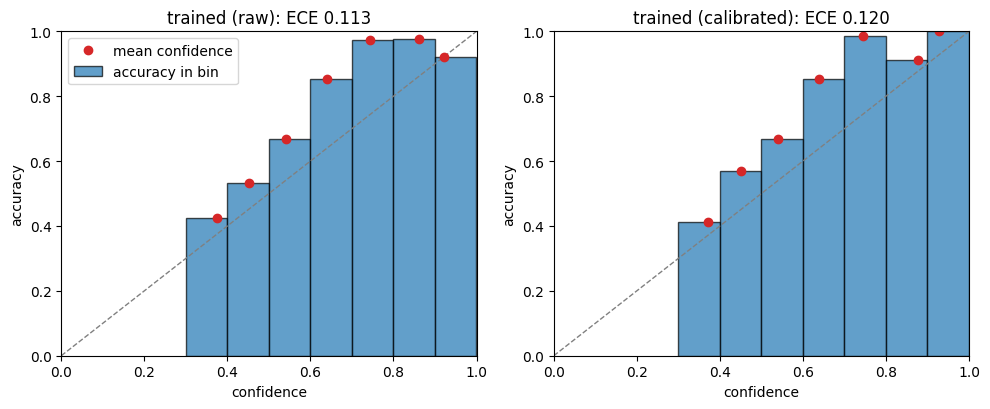

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, name in zip(axes, ["trained (raw)", "trained (calibrated)"]):
    bins = [b for b in results[name]["reliability"] if b["count"]]
    ax.plot([0, 1], [0, 1], "--", color="gray", lw=1)
    ax.bar([b["low"] for b in bins], [b["accuracy"] for b in bins], width=0.1, align="edge", alpha=0.7,
           edgecolor="black", label="accuracy in bin")
    ax.plot([b["confidence"] for b in bins], [b["accuracy"] for b in bins], "o", color="tab:red", label="mean confidence")
    ax.set_title(f"{name}: ECE {results[name]['overall']['ece']:.3f}")
    ax.set_xlabel("confidence"); ax.set_ylabel("accuracy"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
axes[0].legend(loc="upper left")
plt.tight_layout(); plt.show()

## 7. Per-workflow results and published reference points

The reference rows are **publisher-reported** on the same test split (Laya's model card and
fine-tuning notebook). They used a 421M ModernBERT-large checkpoint already RLCD-trained on broad
decision data before fine-tuning. Jev's number was collected by Laya's author through TypeSafe's
API. Treat them as orientation, not a controlled head-to-head.

{
 "agent_trace_observability": 0.688,
 "customer_service": 0.704,
 "invoice_processing": 0.6,
 "security_incidents": 0.69
}


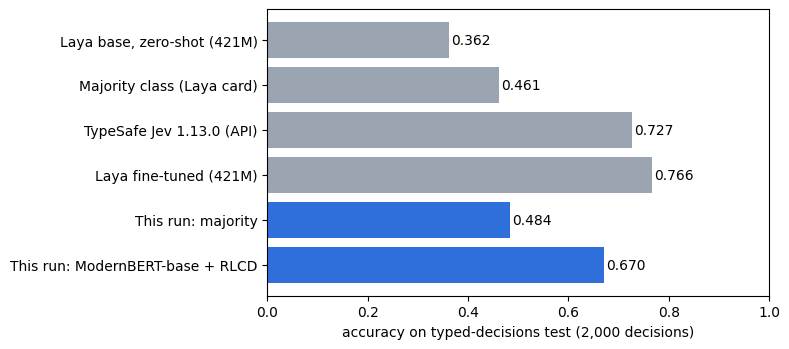

In [14]:
predicted = calibrated_probabilities.argmax(-1)
per_workflow = {}
for workflow in sorted({item.workflow for item in test_items}):
    rows = torch.tensor([item.workflow == workflow for item in test_items])
    per_workflow[workflow] = round(float((predicted[rows] == test_gold[rows]).float().mean()), 4)
print(json.dumps(per_workflow, indent=1))

published = [
    ("Laya base, zero-shot (421M)", 0.362),
    ("Majority class (Laya card)", 0.461),
    ("TypeSafe Jev 1.13.0 (API)", 0.727),
    ("Laya fine-tuned (421M)", 0.766),
]
ours = [
    ("This run: majority", results["majority"]["overall"]["accuracy"]),
    (f"This run: {ENCODER.split('/')[-1]} + RLCD", results["trained (calibrated)"]["overall"]["accuracy"]),
]
fig, ax = plt.subplots(figsize=(8, 3.6))
labels = [n for n, _ in published + ours]
values = [v for _, v in published + ours]
colors = ["#9aa5b1"] * len(published) + ["#2f6fdb"] * len(ours)
ax.barh(labels, values, color=colors)
for y, v in enumerate(values):
    ax.text(v + 0.005, y, f"{v:.3f}", va="center")
ax.set_xlim(0, 1); ax.set_xlabel("accuracy on typed-decisions test (2,000 decisions)")
ax.invert_yaxis(); plt.tight_layout(); plt.show()

## 8. Use it like Jev: `predict(state, questions)`

All questions about one state are encoded as a batch and answered in a single forward pass. The
first request uses a schema from the training workflows; the second invents a brand-new schema at
request time. The model *runs* on any schema, but expect weaker answers outside the four trained
workflows: Laya and Jev get their generality from far broader training data than one benchmark.

In [15]:
agent = DecisionAgent(model, tokenizer, MAX_LEN, HEAD_MAX_LEN, device=DEVICE)

in_domain_case = test_rows[0]
in_domain = agent.predict(json.loads(in_domain_case["state"]), json.loads(in_domain_case["questions"]))
print("workflow:", in_domain_case["workflow"])
for qid, answer in in_domain["answers"].items():
    summary = {k: v for k, v in answer.items() if k != "probabilities"}
    print(f"  {qid:<18} {json.dumps(summary, default=str)}")

ticket = {"subject": "Charged twice", "body": "We were billed twice for March. Refund the duplicate today or we cancel."}
new_schema = {
    "department": {"type": "choice", "instructions": "Which department should handle this?",
                   "criteria": {"billing": "invoices, payments, refunds", "technical": "bugs, outages, errors", "other": "everything else"}},
    "urgency": {"type": "score", "instructions": "How urgent is this?", "criteria": ["not urgent", "soon", "blocking"]},
    "churn_risk": {"type": "noul", "instructions": "Does the customer threaten to cancel or leave?"},
}
novel = agent.predict(ticket, new_schema)
print(json.dumps(novel["answers"], indent=1, default=lambda v: round(v, 3)))

latencies = []
for _ in range(20):
    latencies.append(agent.predict(ticket, new_schema)["latency_ms"])
latencies.sort()
print(f"3 questions, one call: p50 {latencies[10]:.1f} ms, p90 {latencies[18]:.1f} ms on {DEVICE}")

workflow: agent_trace_observability
  action             {"type": "choice", "choice": "continue", "confidence": 0.5388896465301514}
  needs_review       {"type": "noul", "noul": 0.1516191065311432, "confidence": 0.8483808934688568}
  outcome            {"type": "choice", "choice": "success", "confidence": 0.4334968626499176}
  risk               {"type": "score", "score": 0.6948955059051514, "confidence": 0.4902023375034332}
  urgency            {"type": "score", "score": 0.6843956112861633, "confidence": 0.49207890033721924}
{
 "department": {
  "type": "choice",
  "choice": "technical",
  "probabilities": {
   "billing": 0.3687278628349304,
   "technical": 0.42036423087120056,
   "other": 0.21090790629386902
  },
  "confidence": 0.42036423087120056
 },
 "urgency": {
  "type": "score",
  "score": 1.1704686880111694,
  "probabilities": {
   "0": 0.16548165678977966,
   "1": 0.49856799840927124,
   "2": 0.3359503448009491
  },
  "confidence": 0.49856799840927124
 },
 "churn_risk": {
  "

## 9. Save the model and export results for the project site

In [16]:
model.save_pretrained(OUTPUT_DIR / "model")
tokenizer.save_pretrained(OUTPUT_DIR / "model" / "tokenizer")

def rounded(value):
    if isinstance(value, float):
        return round(value, 4)
    if isinstance(value, dict):
        return {k: rounded(v) for k, v in value.items()}
    if isinstance(value, list):
        return [rounded(v) for v in value]
    return value

export = rounded({
    "encoder": ENCODER,
    "objective": OBJECTIVE,
    "quick": QUICK,
    "device": str(DEVICE),
    "epochs": EPOCHS,
    "train_minutes": train_minutes,
    "parameters_m": count(model),
    "decisions": {"train": len(train_items), "calibration": len(calib_items), "test": len(test_items)},
    "temperatures": {name: float(temperatures[idx]) for name, idx in QUESTION_TYPES.items()},
    "results": results,
    "per_workflow": per_workflow,
    "published": dict(published),
    "epoch_log": epoch_log,
    "history": [h for h in history if h["step"] % 10 == 0],
    "demo": {"state": ticket, "questions": new_schema, "answers": novel["answers"],
             "latency_p50_ms": latencies[10]},
})
run_name = f"{ENCODER.split('/')[-1]}-{OBJECTIVE}" + ("-quick" if QUICK else "")
runs_dir = Path("../docs/assets/runs")
if QUICK or not Path("../docs").exists():
    runs_dir = OUTPUT_DIR  # Colab, or a smoke test: keep results next to the model
runs_dir.mkdir(parents=True, exist_ok=True)
results_path = runs_dir / f"{run_name}.json"
results_path.write_text(json.dumps({"name": run_name, **export}, indent=1))

index_path = runs_dir / "index.json"
index = json.loads(index_path.read_text()) if index_path.exists() else []
index = [entry for entry in index if entry["name"] != run_name] + [{
    "name": run_name, "file": results_path.name, "encoder": ENCODER, "objective": OBJECTIVE,
    "accuracy": export["results"]["trained (calibrated)"]["overall"]["accuracy"],
}]
index_path.write_text(json.dumps(index, indent=1))
print("saved model to", OUTPUT_DIR / "model", "and results to", results_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved model to outputs/ModernBERT-base/model and results to outputs/ModernBERT-base/ModernBERT-base-rlcd.json


## 10. Where to go next

* **Bigger backbone:** `answerdotai/ModernBERT-large` matches Laya's English checkpoint (expect
  roughly 3× the compute of base).
* **Broader decision data:** the gap to Laya/Jev on unseen schemas is mostly data. Convert public
  classification sets (AG News, Banking77, SST-5, BoolQ) into `choice`/`score`/`noul` questions
  with natural-language criteria and mix them in.
* **Per-(type, option-count) temperatures**, as Laya recommends for production.
* **Multi-turn RLCD:** Laya applies TD(λ=1) over conversation prefix slices; this dataset is
  single-turn, so that part is not exercised here.
* **Ablation:** rerun with `JEV_OBJECTIVE=ce` to compare plain soft cross-entropy against RLCD on
  ECE and Brier.